# 03 — El producto end-to-end: del scraping a la dirección del dólar

Esta notebook recorre **todo el sistema, en orden y sin saltarse nada**:

| § | Etapa | Qué verás |
|---|---|---|
| 1 | **Scraping de noticias** (Bronze→Silver) | Los titulares crudos del día, sin LLM |
| 2 | **El movimiento de las monedas** | TRM oficial + Brent, DXY y bolsa colombiana |
| 3 | **GOLD: los topics y la golden query** | Cada noticia clasificada (topic, canal FX, severidad, entidades) y la consulta que filtra el oro del ruido |
| 4 | **El grafo de noticias** | Tópicos ↔ entidades con comunidades — los clusters del día |
| 5 | **El sistema multiagéntico** | QUÉ patrón es (la respuesta explícita) + el grafo LangGraph **renderizado** |
| 6 | **La corrida y la predicción** | El grafo completo ejecutándose → `DirectionalCall` |
| 7 | **Medición** | La tabla `predictions` que califica al sistema contra la realidad |

**El objetivo de estudio** (invariante desde el día 1): clasificar la **dirección** del
USD/COP — `down`/`up`/`neutral` — cruzando noticias analizadas por agentes con la señal
de la serie de tiempo, bajo una capa de racionalidad que obliga al contra-argumento y
acota la confianza por contrato.

In [1]:
# Setup — limpio: sin os.chdir, sin adivinar rutas con cwd.
# cop_fx.paths resuelve la raíz desde el paquete y Settings lee el .env absoluto.
import sys

try:
    import cop_fx  # noqa: F401
except ModuleNotFoundError:
    raise RuntimeError(
        f"KERNEL EQUIVOCADO ({sys.executable}).\n"
        "En VS Code: selector de kernel → 'Python (cop-fx-intelligence)'."
    ) from None

from cop_fx.config.settings import get_settings
from cop_fx.paths import DATA_DIR, PROJECT_ROOT

settings = get_settings()
assert settings.openai_api_key is not None, f"Falta OPENAI_API_KEY en {PROJECT_ROOT / '.env'}"

print(f"✓ Proyecto : {PROJECT_ROOT.name}")
print(f"✓ LLM      : {settings.llm_model} ({settings.llm_provider})")
print(f"✓ Datos    : {DATA_DIR}")

✓ Proyecto : cop-fx-intelligence
✓ LLM      : gpt-5.4-mini (openai)
✓ Datos    : /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/data


## 1. Scraping de noticias — Bronze → Silver

Determinista y aburrido a propósito: feeds RSS de economía colombiana, CNN Colombia
(HTML de respaldo) y los feeds macro del lado USD (CNBC, MarketWatch). Cero LLM,
cero costo. El resultado es `list[Article]` — el Silver que alimenta a los agentes.

In [2]:
import pandas as pd

from cop_fx.data.news_fetcher import NewsFetcher

articles = NewsFetcher().fetch()
df_silver = pd.DataFrame(
    {
        "fecha": [a.published_at.strftime("%Y-%m-%d") for a in articles],
        "fuente": [a.source for a in articles],
        "titular": [a.title for a in articles],
    }
)
print(f"✓ {len(articles)} artículos (Silver) — aún sin topics: eso es GOLD y cuesta tokens\n")
df_silver.head(15)

15:33:07  INFO      cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: starting (max=50)


15:33:08  WARNING   cop_fx.data.cnn_fetcher  —  RSS feed returned 0 entries: https://cnnespanol.cnn.com/colombia/feed/


15:33:08  WARNING   cop_fx.data.cnn_fetcher  —  Colombia RSS empty — trying main CNN Español feed


15:33:08  WARNING   cop_fx.data.cnn_fetcher  —  RSS feed returned 0 entries: https://cnnespanol.cnn.com/feed/


15:33:09  SUCCESS   cop_fx.data.cnn_fetcher  —  HTML: fetched 3437430 bytes from https://cnnespanol.cnn.com/colombia/


...

15:33:09  SUCCESS   cop_fx.data.cnn_fetcher  —  HTML: extracted 44 articles


15:33:09  SUCCESS   cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: 44 unique articles ready | with author: 0/44


15:33:09  SUCCESS   cop_fx.data.news_fetcher  —  Fetched 50 unique articles total


✓ 50 artículos (Silver) — aún sin topics: eso es GOLD y cuesta tokens



,fecha,fuente,titular
0,2026-06-12,MarketWatch.com - Top Stories,‘I feel like he may be taking advantage of us’...
1,2026-06-12,PORTAFOLIO.CO -Economía,Marco Fiscal de Media Plazo: Gobierno mantiene...
2,2026-06-12,PORTAFOLIO.CO -Economía,Mintransporte firmará resolución de tarifas di...
3,2026-06-12,MarketWatch.com - Top Stories,Is it too late to buy SpaceX’s stock? Here’s h...
4,2026-06-12,MarketWatch.com - Top Stories,‘It seems too good to be true’: At a steak-din...
5,2026-06-12,MarketWatch.com - Top Stories,Adobe’s CFO is departing for Marvell. And it’s...
6,2026-06-12,PORTAFOLIO.CO -Economía,Sindicato de Ecopetrol anuncia que seguirán mo...
7,2026-06-12,PORTAFOLIO.CO -Economía,Registrador Penagos envía mensaje a candidatos...
8,2026-06-12,MarketWatch.com - Top Stories,There’s a 68% chance the stock market ends the...
9,2026-06-12,MarketWatch.com - Top Stories,Global oil prices end at 3-month low after Pak...


## 2. El movimiento de las monedas

La TRM oficial (datos.gov.co) más el contexto de mercado que el estudio de la
notebook 02 validó: Brent, DXY y la bolsa colombiana (GXG) — recuerda que el equity
de ayer es el único predictor adelantado que pasó el filtro lead-lag.

15:33:09  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


15:33:09  INFO      cop_fx.data.fx_fetcher  —  Fetched 236 FX rows (start=2025-06-12, end=2026-06-12)


15:33:10  INFO      cop_fx.data.market_fetcher  —  Serie brent (BZ=F): 301 filas


15:33:10  INFO      cop_fx.data.market_fetcher  —  Serie dxy (DX-Y.NYB): 301 filas


15:33:11  INFO      cop_fx.data.market_fetcher  —  Serie equity (GXG): 363 filas


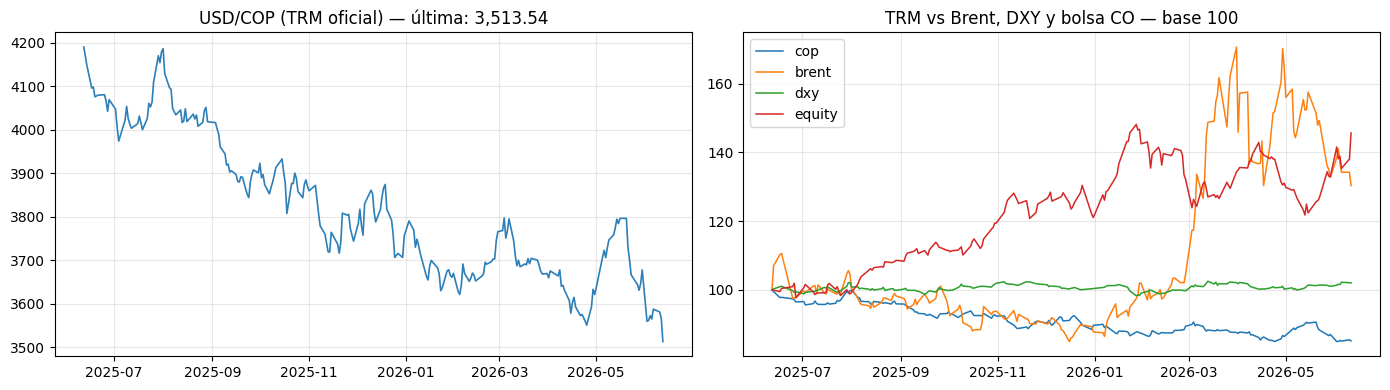

In [3]:
import matplotlib.pyplot as plt

from cop_fx.data.fx_fetcher import FXFetcher
from cop_fx.data.market_fetcher import fetch_market_panel

fx = FXFetcher().fetch()
panel = fetch_market_panel(fx)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(fx["ds"], fx["y"], color="#2c7fb8", lw=1.2)
axes[0].set_title(f"USD/COP (TRM oficial) — última: {fx['y'].iloc[-1]:,.2f}")
axes[0].grid(alpha=0.3)
for col in [c for c in panel.columns if c != "ds"]:
    axes[1].plot(panel["ds"], 100 * panel[col] / panel[col].iloc[0], label=col, lw=1.1)
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("TRM vs Brent, DXY y bolsa CO — base 100")
plt.tight_layout(); plt.show()

## 3. GOLD — los topics y la *golden query*

Aquí el LLM toca el dato por primera vez. El `NewsAnalyzer` (el mismo del pipeline)
clasifica cada artículo con la **taxonomía de dos niveles**:

- `topic`: qué ES la noticia (15 dominios: `political_risk`, `monetary_policy`,
  `public_health`, `environment_climate`, `sports`...)
- `fx_relevance` + `fx_channel`: si transmite al dólar y POR QUÉ mecanismo —
  con coherencia forzada por contrato (deportes ⇒ relevancia `none` ⇒ pesa 0).

In [4]:
from cop_fx.analysis.news_analyzer import NewsAnalyzer

analysis = NewsAnalyzer().analyze(articles[:20])

df_gold = pd.DataFrame([
    {
        "titular": it.article.title[:60],
        "topic": it.topic,
        "fx_relevance": it.fx_relevance,
        "fx_channel": it.fx_channel,
        "severity": it.severity,
        "bullish_cop": it.bullish_cop,
        "entities": ", ".join(it.entities),
    }
    for it in analysis.items
])
print(f"✓ {len(df_gold)} artículos GOLD · narrativa del día:\n{analysis.narrative}\n")
df_gold

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


✓ 20 artículos GOLD · narrativa del día:
El sesgo más relevante para USD/COP viene del petróleo: el Brent cayó a mínimos de tres meses, lo que presiona los términos de intercambio de Colombia. En contraste, los anuncios sobre hub energético y exportaciones limpias en el Caribe son positivos para el mediano plazo, pero hoy tienen impacto limitado. El resto de noticias sugiere ruido macro acotado, con algunos focos menores en inflación, crecimiento y riesgo político, pero sin cambiar la narrativa dominante.



,titular,topic,fx_relevance,fx_channel,severity,bullish_cop,entities
0,‘I feel like he may be taking advantage of us’...,financial_markets,none,none,low,False,
1,Marco Fiscal de Media Plazo: Gobierno mantiene...,fiscal_policy,indirect,inflation,medium,False,"MinHacienda, Germán Ávila, Marco Fiscal de Med..."
2,Mintransporte firmará resolución de tarifas di...,fiscal_policy,none,none,low,False,"Mintransporte, Autopistas del Café, Rojas, Eje..."
3,Is it too late to buy SpaceX’s stock? Here’s h...,financial_markets,none,none,low,False,"SpaceX, Tesla, bitcoin, oro"
4,‘It seems too good to be true’: At a steak-din...,financial_markets,none,none,low,False,
5,Adobe’s CFO is departing for Marvell. And it’s...,financial_markets,indirect,capital_flows,low,False,"Adobe, Marvell, Meta, Citi"
6,Sindicato de Ecopetrol anuncia que seguirán mo...,labor_social,indirect,growth,medium,False,Ecopetrol
7,Registrador Penagos envía mensaje a candidatos...,political_risk,indirect,country_risk,low,False,"Penagos, Medellín"
8,There’s a 68% chance the stock market ends the...,financial_markets,none,none,low,False,
9,Global oil prices end at 3-month low after Pak...,energy_commodities,direct,terms_of_trade,high,False,"Brent, Pakistán, Estados Unidos, Irán"


In [5]:
# LA GOLDEN QUERY: separar el oro del ruido.
# De todo lo scrapeado, ¿qué tiene canal de transmisión al dólar y con qué fuerza?
golden = (
    df_gold[df_gold["fx_relevance"] != "none"]
    .sort_values("severity", key=lambda s: s.map({"high": 0, "medium": 1, "low": 2}))
    .reset_index(drop=True)
)
print(f"Golden query: {len(golden)} de {len(df_gold)} artículos tienen señal FX\n")
display(golden)

print("\nTopic × relevancia FX — cuánto del día es señal vs ruido:")
pd.crosstab(df_gold["topic"], df_gold["fx_relevance"])

Golden query: 11 de 20 artículos tienen señal FX



,titular,topic,fx_relevance,fx_channel,severity,bullish_cop,entities
0,Global oil prices end at 3-month low after Pak...,energy_commodities,direct,terms_of_trade,high,False,"Brent, Pakistán, Estados Unidos, Irán"
1,Marco Fiscal de Media Plazo: Gobierno mantiene...,fiscal_policy,indirect,inflation,medium,False,"MinHacienda, Germán Ávila, Marco Fiscal de Med..."
2,Sindicato de Ecopetrol anuncia que seguirán mo...,labor_social,indirect,growth,medium,False,Ecopetrol
3,Adobe’s CFO is departing for Marvell. And it’s...,financial_markets,indirect,capital_flows,low,False,"Adobe, Marvell, Meta, Citi"
4,Registrador Penagos envía mensaje a candidatos...,political_risk,indirect,country_risk,low,False,"Penagos, Medellín"
5,El Caribe presentó su hoja de ruta para conver...,energy_commodities,indirect,terms_of_trade,low,True,"Caribe, Región Administrativa y de Planeación ..."
6,Colombia tendría 60% más casos de cáncer en 20...,public_health,indirect,growth,low,False,Colombia
7,Corte Constitucional ordena a EPS pagar tratam...,public_health,indirect,inflation,low,False,"Corte Constitucional, EPS"
8,Corte Suprema admite tutela de De La Espriella...,political_risk,indirect,country_risk,low,False,"Corte Suprema, De La Espriella"
9,Sena amplía convocatoria 2026: aún hay 50.000 ...,labor_social,indirect,growth,low,True,Sena



Topic × relevancia FX — cuánto del día es señal vs ruido:


fx_relevance,direct,indirect,none
topic,,,
energy_commodities,1,1,0
financial_markets,0,2,8
fiscal_policy,0,1,1
labor_social,0,2,0
political_risk,0,2,0
public_health,0,2,0


## 4. El grafo de noticias — tópicos ↔ entidades

Tu idea original del proyecto: ver cómo interactúan los temas del día. Grafo bipartito
(tópicos ↔ entidades nombradas), aristas ponderadas por co-mención, **comunidades**
detectadas por modularidad. Cada comunidad es un cluster temático — exactamente la
unidad de trabajo que el orchestrator despacha con `Send` en la sección siguiente.

39 nodos · 33 aristas · 6 comunidades · puentes entre tópicos: ninguno


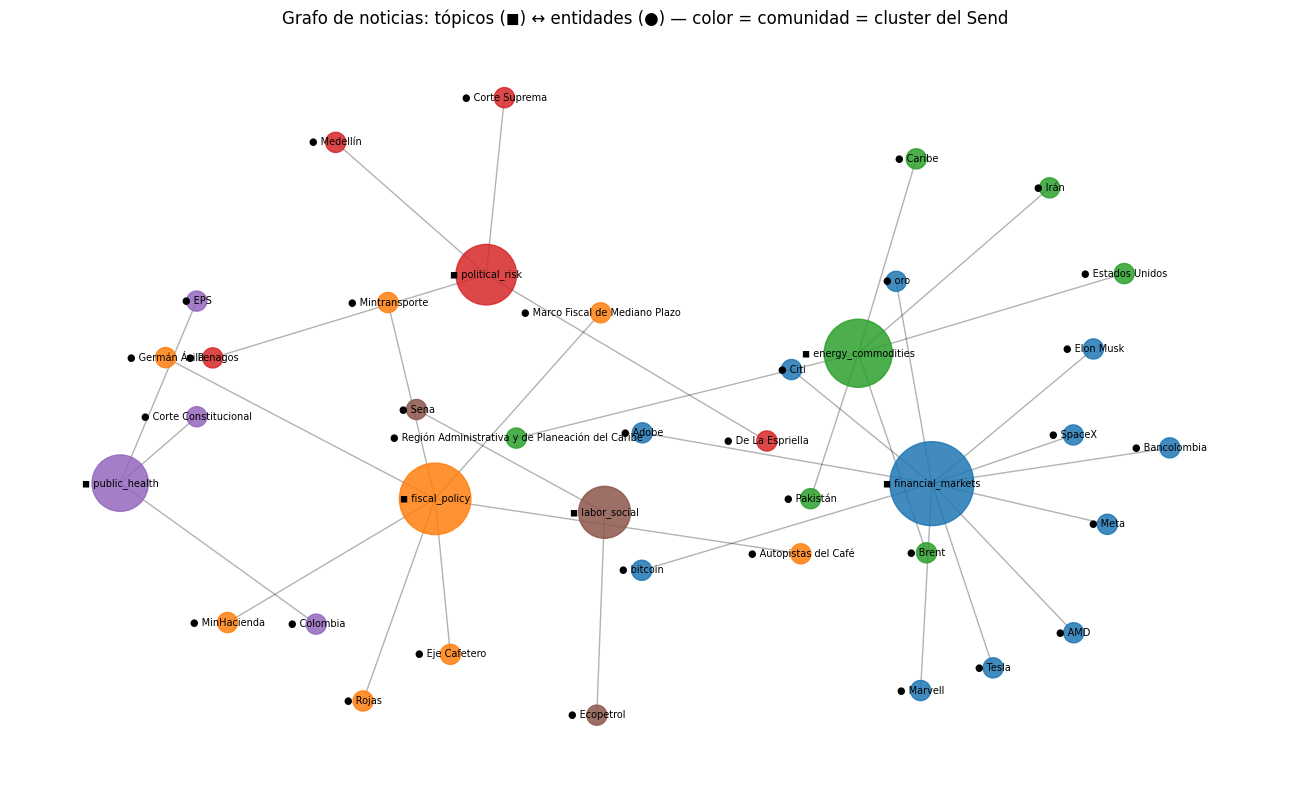

In [6]:
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

G = nx.Graph()
for it in analysis.items:
    t = f"◼ {it.topic}"
    G.add_node(t, kind="topic")
    for e in it.entities:
        en = f"● {e}"
        G.add_node(en, kind="entity")
        w = (G.get_edge_data(t, en) or {}).get("weight", 0)
        G.add_edge(t, en, weight=w + 1)

communities = list(greedy_modularity_communities(G, weight="weight"))
bridges = [n for n in G.nodes if G.nodes[n]["kind"] == "entity"
           and len({nb for nb in G.neighbors(n) if G.nodes[nb]["kind"] == "topic"}) > 1]
print(f"{G.number_of_nodes()} nodos · {G.number_of_edges()} aristas · "
      f"{len(communities)} comunidades · puentes entre tópicos: {bridges or 'ninguno'}")

fig, ax = plt.subplots(figsize=(13, 8))
pos = nx.spring_layout(G, k=0.65, seed=42, weight="weight")
palette = plt.colormaps["tab10"].colors
colors = [palette[next(ci for ci, c in enumerate(communities) if n in c) % 10] for n in G.nodes]
sizes = [900 + 250 * int(G.degree(n)) if G.nodes[n]["kind"] == "topic"
         else 120 + 90 * int(G.degree(n)) for n in G.nodes]
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
ax.set_title("Grafo de noticias: tópicos (◼) ↔ entidades (●) — color = comunidad = cluster del Send")
ax.axis("off"); plt.tight_layout(); plt.show()

## 5. El sistema multiagéntico — la respuesta explícita: ¿qué patrón es?

**No es UN patrón: es una composición de cinco, cada uno resolviendo un problema
distinto.** El dominante es **orchestrator-workers + evaluator**; los demás son capas
de soporte. Este era el dilema original del proyecto ("¿prompt chaining, routing,
parallelization u orchestrator-worker?") y esta es la respuesta final:

| Patrón (tu curso) | Nodo(s) en este sistema | Qué problema resuelve |
|---|---|---|
| **Parallelization** (módulo 12 LCEL / ramas del grafo) | `fetch_fx` ‖ `fetch_market` ‖ `fetch_news` desde START; los N workers en un mismo superstep | Las señales son independientes: descargarlas y analizarlas a la vez |
| **Routing** (módulo 16) | `check_materiality` → `add_conditional_edges` → `orchestrate` o `skip_news` | Control de costo: un día sin noticia material no gasta tokens de análisis |
| **Orchestrator-workers** (módulos 13-15, + la API `Send` que el curso NO cubre) | `orchestrate` → `Send("topic_worker", cluster)` × N → reducers `operator.add` | La cantidad de analistas la decide el DATO (los clusters del §4), no el código — un grafo estático no puede |
| **Prompt chaining** (módulo 03) | dentro de cada `topic_worker`: extraer → clasificar → canal de transmisión → impacto | Sub-pasos secuenciales de razonamiento por cluster |
| **Evaluator / racionalidad** (sin módulo equivalente — aporte original) | `adjudicate` (`defer=True`, tier judge) | Reconcilia noticias vs serie vs contexto de mercado; abogado del diablo obligatorio; confianza ACOTADA por validadores Pydantic, no por el prompt |

**Las dos reglas de oro del diseño:**
1. El LLM solo razona sobre TEXTO; todos los NÚMEROS (señales, pesos, confianza,
   evaluación) los produce código determinista. El modelo no puede inventarse un score.
2. Un nodo nuevo solo entra si toma una decisión que un nodo determinista no podía
   tomar — el multiagente se gana con necesidad, no con ambición.

Importing plotly failed. Interactive plots will not work.


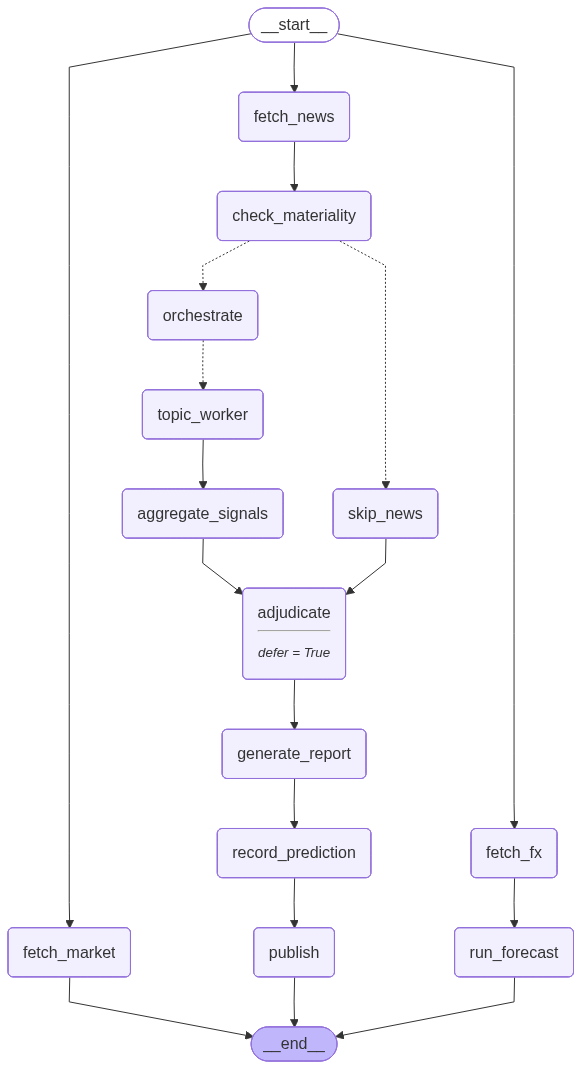

In [7]:
# El grafo LangGraph, RENDERIZADO (no texto): éste es el sistema completo
from IPython.display import Image, display

from cop_fx.agents.graph import build_graph

compiled = build_graph().compile()
try:
    display(Image(compiled.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(f"(render remoto no disponible: {exc} — versión texto)\n")
    print(compiled.get_graph().draw_mermaid())

## 6. La corrida completa → la predicción de la dirección

Todo lo anterior, orquestado en una sola invocación — lo mismo que ejecuta
`uv run cop-fx run` cada día.

In [8]:
from cop_fx.agents.graph import run_pipeline

final_state = run_pipeline()

print("\n=== resumen de la corrida ===")
print(f"TRM            : {final_state.get('latest_rate', 0):,.2f} ({final_state.get('rate_change_pct', 0):+.2f}% 30d)")
print(f"Mercado (ayer) : {final_state.get('market_signal', {})}")
print(f"¿Día material? : {final_state.get('has_material_news')}")
print(f"Clusters (Send): { {t: len(i) for t, i in final_state.get('clusters', {}).items()} }")
print(f"Errores        : {final_state.get('errors', [])}")

15:33:28  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


15:33:28  INFO      cop_fx.data.fx_fetcher  —  Fetched 236 FX rows (start=2025-06-12, end=2026-06-12)


15:33:28  INFO      cop_fx.agents.nodes  —  Market context: down (equity +5.48%, dxy -0.08%, brent -3.97%)


15:33:29  INFO      cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: starting (max=50)


15:33:29  WARNING   cop_fx.data.cnn_fetcher  —  RSS feed returned 0 entries: https://cnnespanol.cnn.com/colombia/feed/


...

15:33:37  INFO      cop_fx.agents.nodes  —  Señal de noticias: up (score=-0.65, drivers=0)


15:33:41  INFO      cop_fx.agents.nodes  —  DirectionalCall: down (confianza=0.48, reconciliación=diverge)


15:33:41  INFO      cop_fx.tracking.predictions  —  Prediction saved: 2026-06-12 → down (0.48)


15:33:41  INFO      cop_fx.agents.nodes  —  publish: skipped (publish_enabled=False)



=== resumen de la corrida ===
TRM            : 3,513.54 (-2.22% 30d)
Mercado (ayer) : {'direction': 'down', 'equity_ret_1d_pct': 5.485, 'dxy_ret_1d_pct': -0.079, 'brent_ret_1d_pct': -3.972}
¿Día material? : True
Clusters (Send): {'political_risk': 5, 'fiscal_policy': 2, 'energy_commodities': 2, 'public_health': 2, 'us_global_macro': 2, 'other': 3}
Errores        : []


In [9]:
call = final_state["directional_call"]
ARROW = {"down": "⬇️ USD/COP BAJA (COP se fortalece)",
         "up": "⬆️ USD/COP SUBE (COP se debilita)",
         "neutral": "⏸️ NEUTRAL — abstención"}

print("=" * 70)
print(f"  {ARROW[call['direction']]}")
print(f"  confianza {call['confidence']:.2f} · horizonte {call['horizon_days']}d · reconciliación: {call['reconciliation']}")
print("=" * 70)
print(f"  noticias : {call['news_signal']['direction']} (score {call['news_signal']['score']})")
print(f"  serie    : {call['ts_signal']['direction']} ({call['ts_signal']['yhat_delta_pct']:+.2f}%)")
print(f"  mercado  : {final_state.get('market_signal', {}).get('direction', 'n/d')} (contexto, no voto)")
print("-" * 70)
print(f"RACIONAL:\n{call['rationale']}\n")
print(f"ABOGADO DEL DIABLO:\n{call['devils_advocate']}")

  ⬇️ USD/COP BAJA (COP se fortalece)
  confianza 0.48 · horizonte 7d · reconciliación: diverge
  noticias : up (score -0.65)
  serie    : down (-0.45%)
  mercado  : down (contexto, no voto)
----------------------------------------------------------------------
RACIONAL:
Las señales divergen: la noticia agregada apunta a USD/COP al alza (news_signal.direction=up, score=-0.65), mientras que el ensemble de serie temporal apunta a baja (ts_signal.direction=down, yhat_delta_pct=-0.447). Para 7 días, doy más peso al componente temporal porque el sesgo de noticias es mixto y de severidad moderada-baja: el ruido político y el riesgo fiscal/inflación en Colombia presionan al alza el USD/COP, pero el canal más claro del día es la caída del petróleo, que favorece al COP, y además el contexto de mercado muestra un rebote fuerte de la bolsa colombiana (+5.485% ayer), el único indicador validado como leading para USD/COP y consistente con apreciación del COP. En conjunto, el balance entre noticias y

## 7. Medición — el sistema rinde cuentas

Cada corrida deja su predicción en `predictions`; al vencer el horizonte se califica
sola contra la TRM real. Hit-rate, matriz de confusión y accuracy-por-confianza son
las métricas (dirección, no MAPE). El backtest de la serie vive en la notebook 02.

In [10]:
from cop_fx.tracking import PredictionStore

preds = PredictionStore().all()
print(f"{len(preds)} predicciones registradas")
preds[["run_date", "direction", "confidence", "reconciliation",
       "news_direction", "ts_direction", "latest_rate", "actual_direction", "hit"]]

1 predicciones registradas


,run_date,direction,confidence,reconciliation,news_direction,ts_direction,latest_rate,actual_direction,hit
0,2026-06-12,down,0.48,diverge,up,down,3513.54,None,None


In [11]:
# Conclusión GENERADA de esta corrida
ns, ts = call["news_signal"], call["ts_signal"]
mkt = final_state.get("market_signal", {})
print(f"""
┌─ CONCLUSIÓN DE LA CORRIDA ─────────────────────────────────────────
│ {len(final_state.get('raw_articles', []))} titulares → día {'MATERIAL' if final_state.get('has_material_news') else 'no material'} → {len(final_state.get('clusters', {}))} analistas (Send) → {len(final_state.get('analyzed_articles', []))} artículos GOLD
│
│ noticias: {ns['direction']:>7} (score {ns['score']:+.2f})   serie: {ts['direction']:>7} ({ts['yhat_delta_pct']:+.2f}%)
│ mercado : {mkt.get('direction', 'n/d'):>7} (equity ayer {mkt.get('equity_ret_1d_pct', 0):+.2f}%)
│
│ VEREDICTO: USD/COP {call['direction'].upper()} a {call['horizon_days']} días · confianza {call['confidence']:.2f} · {call['reconciliation']}
│ Registrado en data/predictions.db — se autocalifica al vencer el horizonte.
└────────────────────────────────────────────────────────────────────
""")


┌─ CONCLUSIÓN DE LA CORRIDA ─────────────────────────────────────────
│ 50 titulares → día MATERIAL → 6 analistas (Send) → 16 artículos GOLD
│
│ noticias:      up (score -0.65)   serie:    down (-0.45%)
│ mercado :    down (equity ayer +5.49%)
│
│ VEREDICTO: USD/COP DOWN a 7 días · confianza 0.48 · diverge
│ Registrado en data/predictions.db — se autocalifica al vencer el horizonte.
└────────────────────────────────────────────────────────────────────



---
## Cierre

Acabas de ver el sistema completo: **scraping → monedas → golden query (topics) →
grafo de noticias → sistema multiagéntico (routing + Send + chaining + evaluator) →
predicción de la dirección → medición**. Los otros dos cuadernos profundizan las
patas: `01_noticias` (la ingesta y la taxonomía) y `02_series_de_tiempo` (el
diagnóstico cuantitativo y qué activos se ganaron su lugar).

**Para dominar LangGraph replicando esto**: reconstruye el grafo en una notebook
vacía en este orden — (1) un nodo con `with_structured_output`, (2) el router con
`add_conditional_edges`, (3) el fan-out con `Send` + reducers, (4) el join con
`defer=True` y un solo trigger. Verifícate contra `tests/unit/test_graph_nodes.py`.